In [20]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pandas as pd
from jax import config, random
import numpyro, jax
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, init_to_value
config.update('jax_enable_x64', True)
numpyro.set_platform('cpu')
num_chains = 4
numpyro.set_host_device_count(num_chains)
print ('# jax device count:', jax.local_device_count())

# jax device count: 4


In [21]:
import importlib_resources
from jnkepler.jaxttv.infer import *
from jnkepler.nbodytransit import *


In [22]:
import seaborn as sns
sns.set(style='ticks', font_scale=1.6, font='times')
plt.rcParams["figure.figsize"] = (12,6)
from matplotlib import rc

# Load data

In [23]:
d = pd.read_csv("toi_1339_transit_data_all_planets.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])
# d = pd.read_csv("toi_1339_transit_data_all.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])

print(d)

     Planet_num  Index           Tc    Tc_err
0             1      0  1715.354632  0.001001
1             1      2  1733.116272  0.001416
2             1      3  1741.996592  0.001416
3             1      5  1759.759235  0.002002
4             1      6  1768.637553  0.003743
..          ...    ...          ...       ...
106           3     42  3354.303037  0.002314
107           3     43  3392.660442  0.001416
108           3     47  3546.074046  0.001416
109           3     49  3622.769837  0.002238
110           3     50  3661.127242  0.001416

[111 rows x 4 columns]


<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_37468/700704542.py:1: SyntaxWarning: invalid escape sequence '\s'
  d = pd.read_csv("toi_1339_transit_data_all_planets.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])


In [32]:
tcobs = [jnp.array(d.Tc[d.Planet_num==j+1]) for j in range(3)]
errorobs = [jnp.array(d.Tc_err[d.Planet_num==j+1]) for j in range(3)]
p_init = [8.88, 28.579657965796578, 38.35013501350135]

# tcobs = [jnp.array(d.Tc[d.Planet_num==j+2]) for j in range(2)]
# errorobs = [jnp.array(d.Tc_err[d.Planet_num==j+2]) for j in range(2)]
# p_init = [28.579657965796578, 38.35013501350135]

t_start = 1715.  # start of integration
t_end = 3670.
dt = 0.1 # integration timestep

In [33]:
print(tcobs)

[Array([1715.3546315, 1733.1162725, 1741.9965925, 1759.7592345,
       1768.6375525, 1786.3991935, 1795.2825165, 1804.1598335,
       1813.0421555, 1821.9174705, 1830.8017945, 1839.6811135,
       1875.2013925, 1892.9630335, 1901.8433535, 1910.7216715,
       1919.6019915, 1964.0035915, 1972.8839115, 1981.7652325,
       1990.6445515, 1999.5248715, 2008.405692 , 2425.7812325,
       2434.6625535, 2443.5428735, 2621.1512755, 2630.0275915,
       2647.7892325, 2656.6685515, 2701.0721535, 2718.8327935,
       2727.7111115, 2736.5914315, 2798.7546725, 2807.6349925,
       2816.5143115, 2825.3956325, 2834.2779545, 2843.156773 ,
       2852.0375935, 2914.1968305, 2923.0781515, 2931.9574705,
       2940.8397925, 2949.7201125, 2958.6014335, 3296.0505905,
       3340.4541925, 3349.3345125, 3358.2128305, 3367.0961535,
       3375.9744715, 3384.8537905, 3393.7391155, 3402.6174335,
       3420.3760715, 3438.1377125, 3447.0180325, 3455.8993535,
       3464.7786725, 3473.6619955, 3535.8242355, 3544.

In [34]:
# detrended light curves around transits; here simultaneous transit is excluded
dlc = pd.read_csv("TOI1339_lc_photodyn.csv")
time_obs = jnp.array(dlc['time'])
flux_obs = jnp.array(dlc['flux']) - 1.  # normalize around 0
error_obs = jnp.array(dlc['flux_err'])

# Get the sorting indices
sort_idx = np.argsort(time_obs)

# Apply the same reordering to all arrays
time_obs = time_obs[sort_idx]
flux_obs = flux_obs[sort_idx]
error_obs = error_obs[sort_idx]
print(time_obs)

[1711.36577373 1711.36716265 1711.36855156 ... 3662.82669654 3662.82692802
 3662.8271595 ]


In [35]:
window = 0.5  # days
time_segments, flux_segments, error_segments = [], [], []

for planet_idx, tplanet in enumerate(tcobs):
    for t0 in tplanet:
        mask = (time_obs > t0 - window) & (time_obs < t0 + window)
        time_segments.append(time_obs[mask])
        flux_segments.append(flux_obs[mask])
        error_segments.append(error_obs[mask])

# Concatenate segments
time_obs_trim = np.concatenate(time_segments)
flux_obs_trim = np.concatenate(flux_segments)
error_obs_trim = np.concatenate(error_segments)

time_obs = jnp.array(time_obs_trim)
flux_obs = jnp.array(flux_obs_trim)
error_obs = jnp.array(error_obs_trim)

# Initialize

In [36]:
nt = NbodyTransit(t_start, t_end, dt, tcobs, p_init, errorobs=errorobs, print_info=True)
# nt.set_lcobs(time_obs)
nt.set_lcobs(time_obs, exposure_time=2/1440.)

# number of transiting planets:    3
# integration starts at:           1715.00
# first transit time in data:      1715.35
# last transit time in data:       3661.13
# integration ends at:             3670.00
# integration time step:           0.1000 (1/88 of innermost period)

# exposure time (min):             2.0
# supersampling factor:            10


/opt/homebrew/anaconda3/envs/tess-old/lib/python3.12/site-packages/jnkepler/nbodytransit/nbodytransit.py:72: UserWarning: set overlapping_transit to True if overlapping transits are present in the data.
  warnings.warn(


In [37]:
print(nt.times_lc)  # should be a JAX array of times
print(time_obs.shape, flux_obs.shape, error_obs.shape)
print([x.shape for x in tcobs])

[1714.85471387 1714.85610278 1714.85749169 ... 3661.62672085 3661.62695232
 3661.6271838 ]
(333967,) (333967,) (333967,)
[(72,), (22,), (17,)]


# TTV only optimization

In [38]:
param_bounds_ttv = ttv_default_parameter_bounds(nt)#, emax=0.5)

# running least squares optimization...


/opt/homebrew/anaconda3/envs/tess-old/lib/python3.12/site-packages/jnkepler/jaxttv/infer.py:97: UserWarning: Bounds for cosi/lnode not provided: assuming coplanar orbits.
  warnings.warn(


# objective function: 77314.48 --> 148.19 (111 data)
# elapsed time: 11.9 sec
{'period': array([ 8.88024929, 28.58105936, 38.35127389]), 'ecosw': array([ 0.18967285, -0.03122826, -0.02854283]), 'esinw': array([ 0.02429598, -0.02812115, -0.02376113]), 'tic': array([1715.35537921, 1726.05347036, 1743.5556377 ]), 'lnpmass': array([-10.93680148, -11.36203103, -11.92638369]), 'pmass': Array([1.77912912e-05, 1.16287389e-05, 6.61359162e-06], dtype=float64)}


/opt/homebrew/anaconda3/envs/tess-old/lib/python3.12/site-packages/jnkepler/jaxttv/jaxttv.py:523: UserWarning: using t0 and P from a linear fit to the observed transit times.
  warnings.warn(


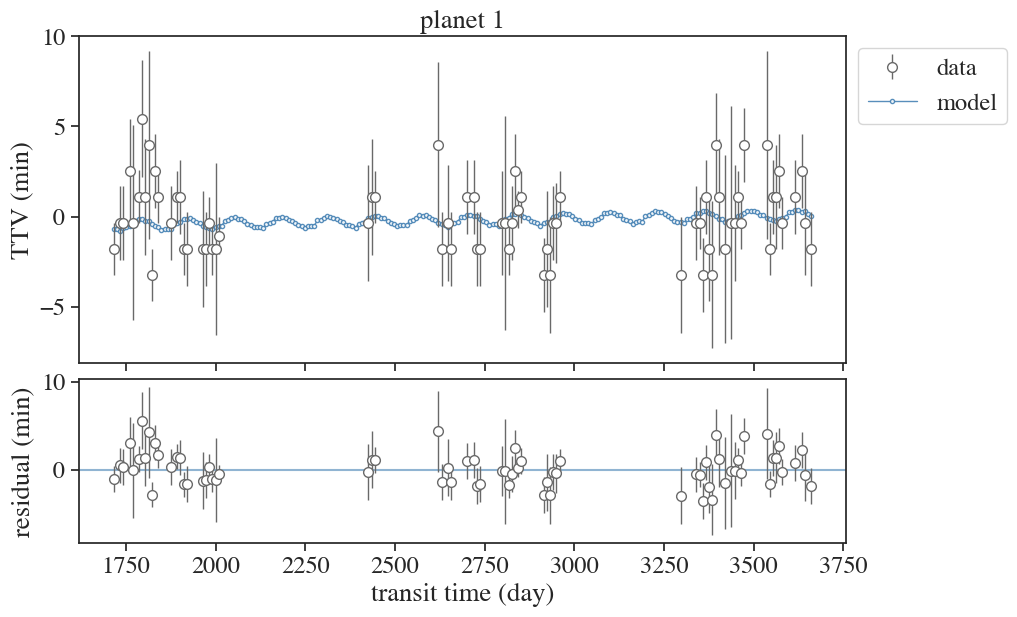

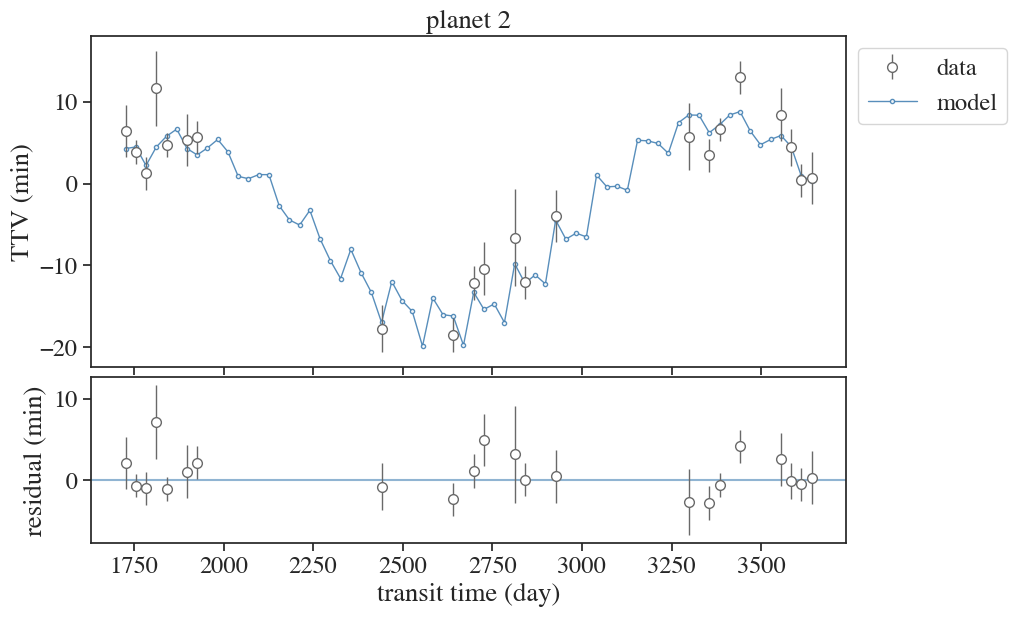

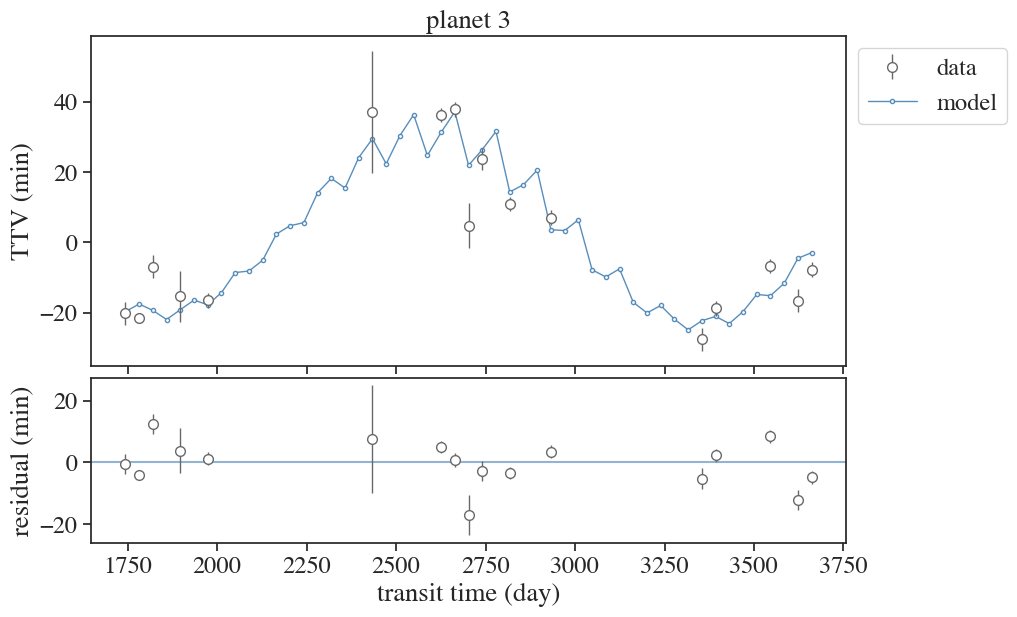

In [39]:
p_init = np.array([8.87594849, 28.579657965796578, 38.35013501350135, 
                   0.0, 0.05, 0.05, 
                   0.0, 0.05, 0.05, 
                   1715.3049092, 1726.05430737, 1743.55228223, 
                   -10.41341358, -10.92425031, -11.61737528])

# p_init = np.array([28.579657965796578, 38.35013501350135, 
#                    -0.21369753, -0.18361236, 
#                    -0.23016884, -0.19734158, 
#                    1726.05430737, 1743.55228223, 
#                    -10.97106092, -11.30491702])

popt = ttv_optim_curve_fit(nt, param_bounds_ttv) #, p_init=p_init)
print(popt)

In [13]:
import pickle 
with open('1339_jnkep_initial_fit_data_photodyn.pkl', 'wb') as f:
    pickle.dump({'jttv': nt, 'popt': popt, 'param_bounds': param_bounds_ttv}, f)

print('Initial fit data saved successfully')

Initial fit data saved successfully


# Transit parameter optimization

In [14]:
from jnkepler.infer import optim_svi

In [15]:
popt["smass"] = 0.81

In [16]:
keys_ttv = ["ecosw", "esinw", "pmass", "period", "tic"]
keys_transit = ["radius_ratio", "b", "srad", "q1", "q2", "meanflux"]
param_bounds_transit = {
    "q1": [jnp.array(0), jnp.array(1.)],
    "q2": [jnp.array(0), jnp.array(1.)],
    "radius_ratio":  [jnp.zeros(3), jnp.ones(3)*0.1],
    "b": [jnp.zeros(3), jnp.ones(3)*1.1],
    "srad": [jnp.array(0.5), jnp.array(1.5)],
    "meanflux": [jnp.array(-1e-4), jnp.array(1e-4)]
}

In [17]:
import celerite2
from celerite2.jax import terms as jax_terms

def model_fix_ttv(par_dict, param_bounds_transit):
    par = {}

    for key in keys_ttv + ["smass"]:
        par[key] = par_dict[key]

    for key in keys_transit:
        if key in ["q1", "q2", "b"]:
            par[key] = numpyro.sample(key, dist.Uniform(param_bounds_transit[key][0], param_bounds_transit[key][1]))
        else:
            par[key+"_scaled"] = numpyro.sample(key+"_scaled", dist.Uniform(param_bounds_transit[key][0]*0, param_bounds_transit[key][0]*0+1.))
            par[key] = numpyro.deterministic(key, par[key+"_scaled"] * (param_bounds_transit[key][1] - param_bounds_transit[key][0]) + param_bounds_transit[key][0])

    
    fluxmodel, tcmodel = nt.get_flux(par)
    numpyro.deterministic("tcmodel", tcmodel)
    fluxmodel = numpyro.deterministic("fluxmodel", fluxmodel)    
    residual = numpyro.deterministic("residual", flux_obs - fluxmodel - par["meanflux"])
    numpyro.deterministic("normed_residual", residual / error_obs)
    
    # GP likelihood
    lna = numpyro.sample("lna", dist.Uniform(low=-14, high=-4))
    lnc = numpyro.sample("lnc", dist.Uniform(low=-5, high=1))
    lnjitter = numpyro.sample("lnjitter", dist.Uniform(low=-14, high=-4))
    jitter = numpyro.deterministic("jitter", jnp.exp(lnjitter))
    kernel = jax_terms.Matern32Term(sigma=jnp.exp(lna), rho=jnp.exp(lnc))
    gp = celerite2.jax.GaussianProcess(kernel, mean=0.0)
    gp.compute(nt.times_lc, diag=error_obs**2 + jitter**2)
    numpyro.sample("obs", gp.numpyro_dist(), obs=residual)
    numpyro.deterministic("gppred", gp.predict(residual))

In [18]:
popt_transit = optim_svi(model_fix_ttv, 1e-2, 5000, p_initial=popt, par_dict=popt, param_bounds_transit=param_bounds_transit)


/opt/homebrew/anaconda3/envs/tess-old/lib/python3.12/site-packages/jaxtyping/__init__.py:231: UserWarning: jaxtyping version >=0.2.23 should be used with Equinox version >=0.11.1
  warnings.warn(
/opt/homebrew/anaconda3/envs/tess-old/lib/python3.12/site-packages/jnkepler/infer.py:115: SyntaxWarning: invalid escape sequence '\m'
  label='normal, $\mathrm{SD}=%.2f$' % sd)
/opt/homebrew/anaconda3/envs/tess-old/lib/python3.12/site-packages/jnkepler/infer.py:117: SyntaxWarning: invalid escape sequence '\m'
  label='normal, $\mathrm{SD}=1$')
/opt/homebrew/anaconda3/envs/tess-old/lib/python3.12/site-packages/jnkepler/infer.py:126: SyntaxWarning: invalid escape sequence '\m'
  label='normal, $\mathrm{SD}=%.2f$' % sd)
/opt/homebrew/anaconda3/envs/tess-old/lib/python3.12/site-packages/jnkepler/infer.py:128: SyntaxWarning: invalid escape sequence '\m'
  label='normal, $\mathrm{SD}=1$')


RuntimeError: Cannot find valid initial parameters. Please check your model again.

In [ ]:
from scipy.stats import norm 
def check_residuals(p):
    bins = np.linspace(-7, 7, 100)
    plt.yscale("log")
    plt.xlabel("normalized residual from GP mean")
    res = (p['residual'] - p["gppred"]) / error_obs
    plt.hist(res, bins=bins, density=True, alpha=0.6, label="SD=%.2f"%np.std(res))
    plt.ylim(plt.gca().get_ylim())
    plt.plot(bins, norm.pdf(bins), color='gray', label='standard normal')
    plt.legend(loc='best')
    plt.ylabel("PDF");

In [ ]:
check_residuals(popt_transit)

In [ ]:
# import jax, numpyro, celerite2
# print(jax.__version__)
# print(numpyro.__version__)
# print(celerite2.__version__)